In [1]:
# for colab
try:
    import google.colab

    !curl -LsSf https://astral.sh/uv/install.sh | sh
    !git clone https://github.com/stanfish06/micropattern.git /tmp/micropattern
    !cp -r /tmp/micropattern/. .
    !rm -rf /tmp/micropattern
    !pip install -e .
    import sys

    sys.path.insert(0, "/content/src")

    # remember to upload aws credentials
    !mkdir -p ~/.aws
    !cp /content/credentials ~/.aws
    !ls ~/.aws
except ImportError:
    raise RuntimeError(
        "make sure to connect to colab kernel or code above will wipe locally"
    )

downloading uv 0.10.2 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Cloning into '/tmp/micropattern'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 116 (delta 64), reused 87 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 2.81 MiB | 7.40 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Obtaining file:///content
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scprep to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            52Gi       971Mi        47Gi       3.0Mi       4.4Gi        51Gi
Swap:             0B          0B          0B


In [3]:
!nvidia-smi

Fri Feb 13 15:06:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import micropattern as mic
from pathlib import Path
import scprep
import scanpy as sc
import pandas as pd

cwd = Path(".").resolve()
print(cwd)

/content


# Data download and prep

In [8]:
mic.io.fetch_minn(cwd)

100%|██████████| 1/1 [00:00<00:00, 13.07it/s]


100%|██████████| 1/1 [00:00<00:00,  6.68it/s]


100%|██████████| 1/1 [00:00<00:00,  1.58it/s]


100%|██████████| 1/1 [00:00<00:00, 16.83it/s]


100%|██████████| 1/1 [00:00<00:00, 16.50it/s]


...

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


100%|██████████| 1/1 [00:00<00:00, 13.25it/s]


100%|██████████| 1/1 [00:00<00:00, 16.39it/s]


100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


100%|██████████| 1/1 [00:00<00:00, 14.22it/s]


In [4]:
sample_list = []
for f in (cwd / "minn_data").glob("*.matrix.tsv.gz"):
    if f.is_file():
        sample_list.append(f.name.split(".")[0])
sample_list = list(set(sample_list))
sample_list.sort()
sample_list

['GSM5176718_gastruloid_0h_1',
 'GSM5176719_gastruloid_0h_2',
 'GSM5176720_gastruloid_12h_1',
 'GSM5176721_gastruloid_12h_2',
 'GSM5176722_gastruloid_24h_1',
 'GSM5176723_gastruloid_24h_2']

In [5]:

data_path = cwd / "minn_data"
data_list = {}
for s in sample_list:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.tsv.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = dat.columns.str.replace(" Gene Expression", "")
    dat.columns = pd.Index(
        [g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")]
    )
    data_list[s] = dat

GSM5176718_gastruloid_0h_1
GSM5176719_gastruloid_0h_2
GSM5176720_gastruloid_12h_1
GSM5176721_gastruloid_12h_2
GSM5176722_gastruloid_24h_1
GSM5176723_gastruloid_24h_2


# QC

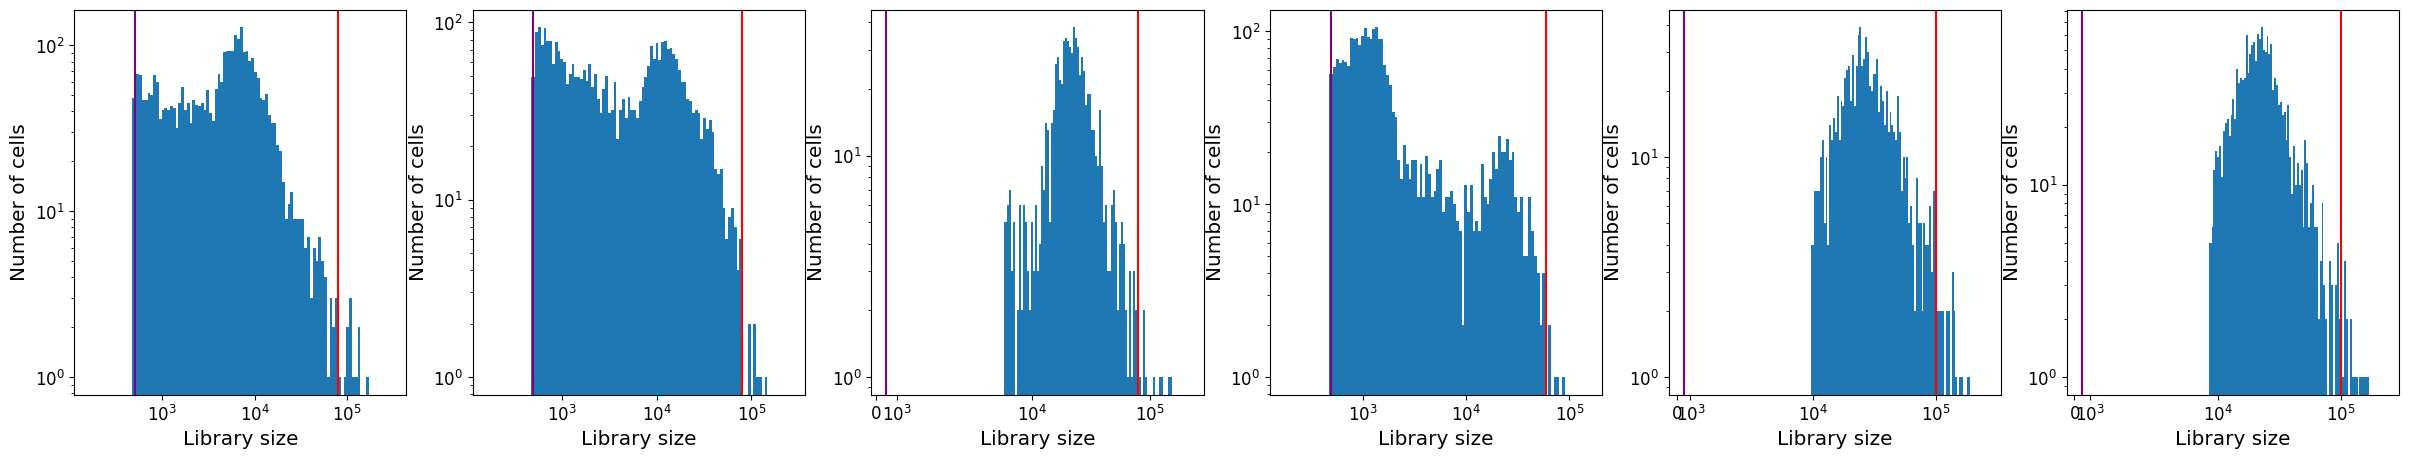

In [6]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(1, len(data_list), figsize=(5 * len(data_list), 5))
thresholds = [
    (500, 8e4),
    (500, 8e4),
    (500, 8e4),
    (500, 6e4),
    (500, 1e5),
    (500, 1e5),
]
for (s, dat), (ax, th) in zip(data_list.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color="red")
    ax.axvline(th[0], color="purple")

before lib filtGSM5176718_gastruloid_0h_1: (3183, 32738)
after lib filt GSM5176718_gastruloid_0h_1: (3169, 32738)
after gene filt GSM5176718_gastruloid_0h_1: (3169, 16383)
before lib filtGSM5176719_gastruloid_0h_2: (3381, 32738)
after lib filt GSM5176719_gastruloid_0h_2: (3373, 32738)
after gene filt GSM5176719_gastruloid_0h_2: (3373, 17785)
before lib filtGSM5176720_gastruloid_12h_1: (784, 33694)
after lib filt GSM5176720_gastruloid_12h_1: (774, 33694)
after gene filt GSM5176720_gastruloid_12h_1: (774, 15087)
before lib filtGSM5176721_gastruloid_12h_2: (2492, 32738)
after lib filt GSM5176721_gastruloid_12h_2: (2484, 32738)
after gene filt GSM5176721_gastruloid_12h_2: (2484, 14852)
before lib filtGSM5176722_gastruloid_24h_1: (975, 33694)
after lib filt GSM5176722_gastruloid_24h_1: (951, 33694)
after gene filt GSM5176722_gastruloid_24h_1: (951, 15548)
before lib filtGSM5176723_gastruloid_24h_2: (1608, 33694)
after lib filt GSM5176723_gastruloid_24h_2: (1590, 33694)
after gene filt GSM51

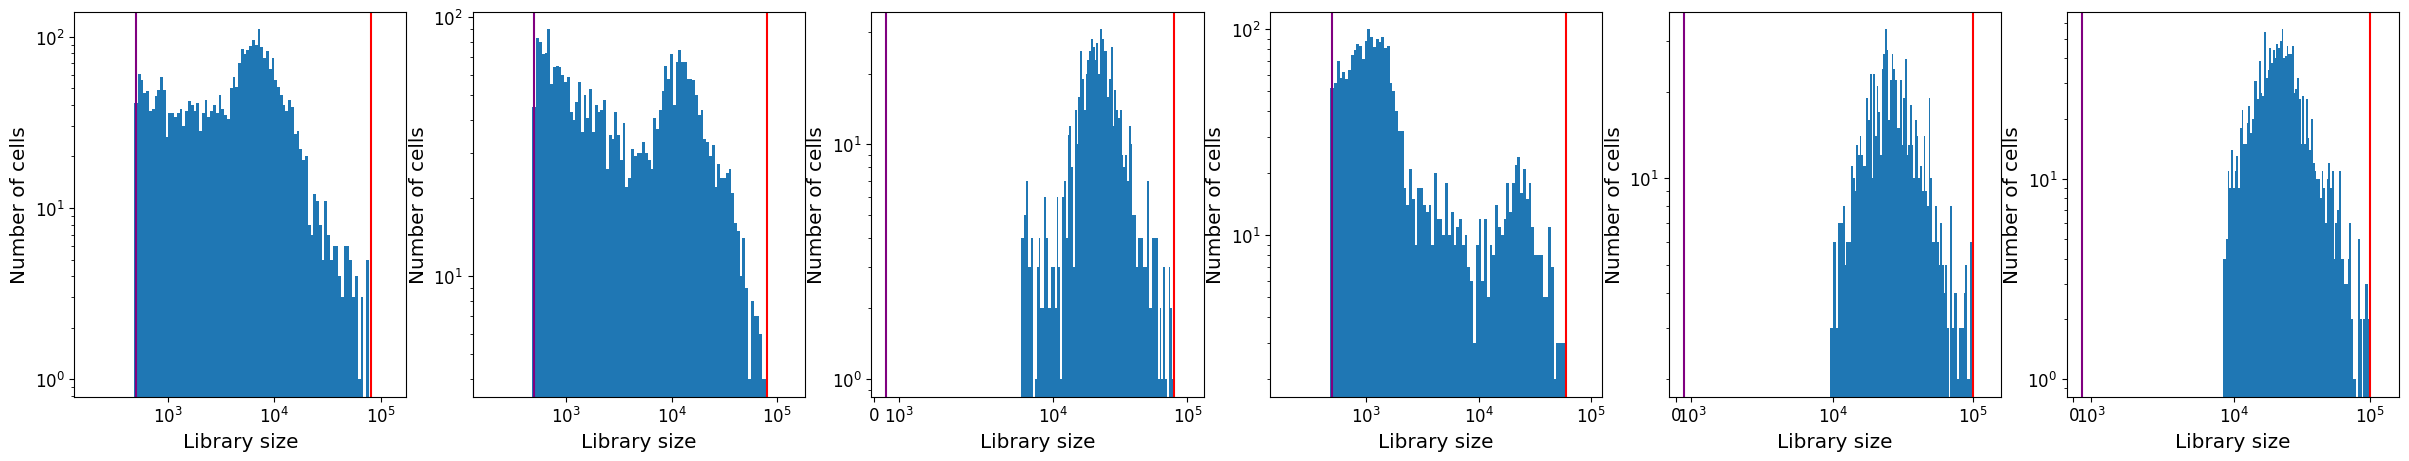

In [7]:
data_list_filt = {}
for (s, dat), th in zip(data_list.items(), thresholds):
    print(f"before lib filt{s}: {dat.shape}")
    dat = scprep.filter.filter_library_size(data=dat, cutoff=th)
    print(f"after lib filt {s}: {dat.shape}")
    dat = scprep.filter.remove_rare_genes(dat, cutoff=0, min_cells=5)
    print(f"after gene filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), (ax, th) in zip(data_list_filt.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color="red")
    ax.axvline(th[0], color="purple")

before mito filtGSM5176718_gastruloid_0h_1: (3169, 16383)
after mito filt GSM5176718_gastruloid_0h_1: (3041, 16383)
before mito filtGSM5176719_gastruloid_0h_2: (3373, 17785)
after mito filt GSM5176719_gastruloid_0h_2: (3238, 17785)
before mito filtGSM5176720_gastruloid_12h_1: (774, 15087)
after mito filt GSM5176720_gastruloid_12h_1: (743, 15087)
before mito filtGSM5176721_gastruloid_12h_2: (2484, 14852)
after mito filt GSM5176721_gastruloid_12h_2: (2384, 14852)
before mito filtGSM5176722_gastruloid_24h_1: (951, 15548)
after mito filt GSM5176722_gastruloid_24h_1: (912, 15548)
before mito filtGSM5176723_gastruloid_24h_2: (1590, 16147)
after mito filt GSM5176723_gastruloid_24h_2: (1526, 16147)


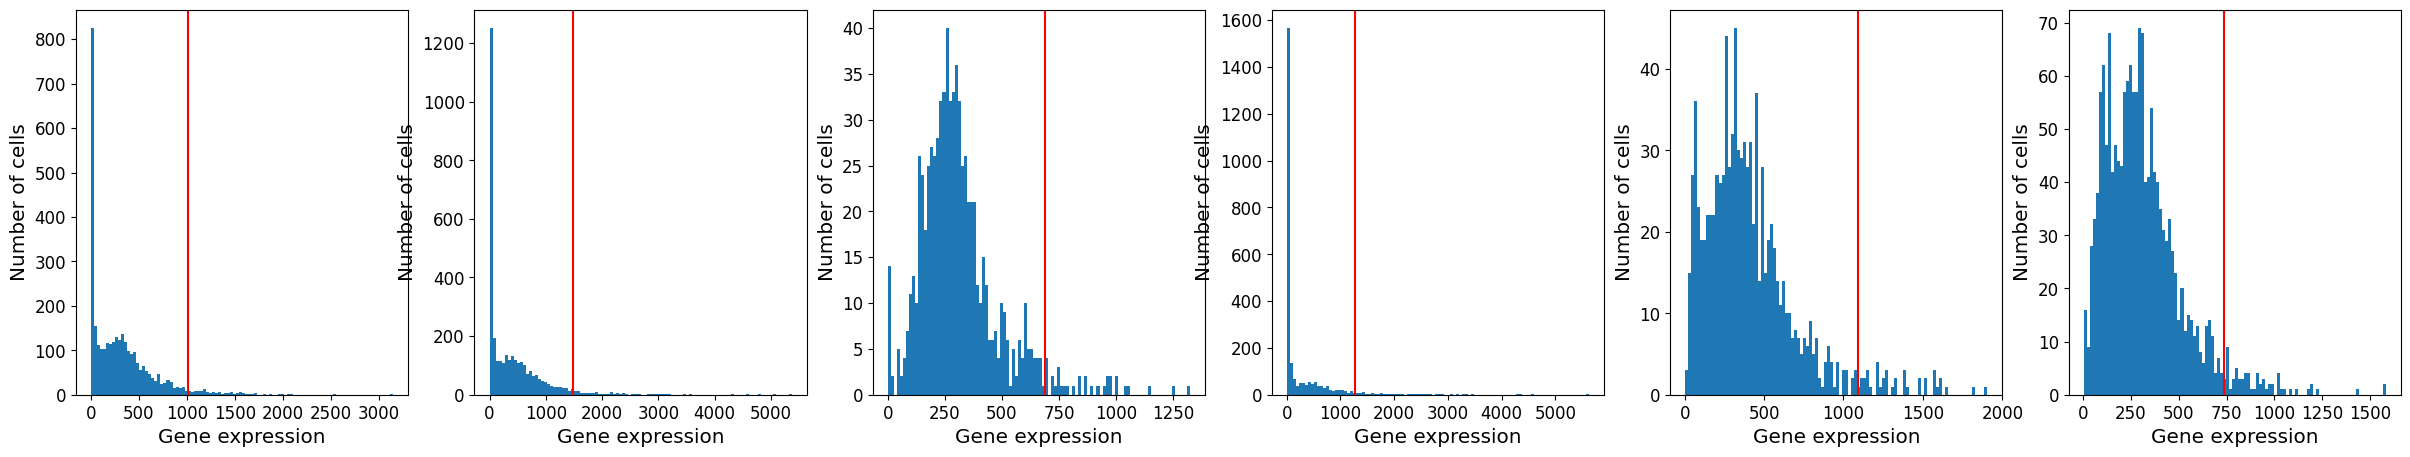

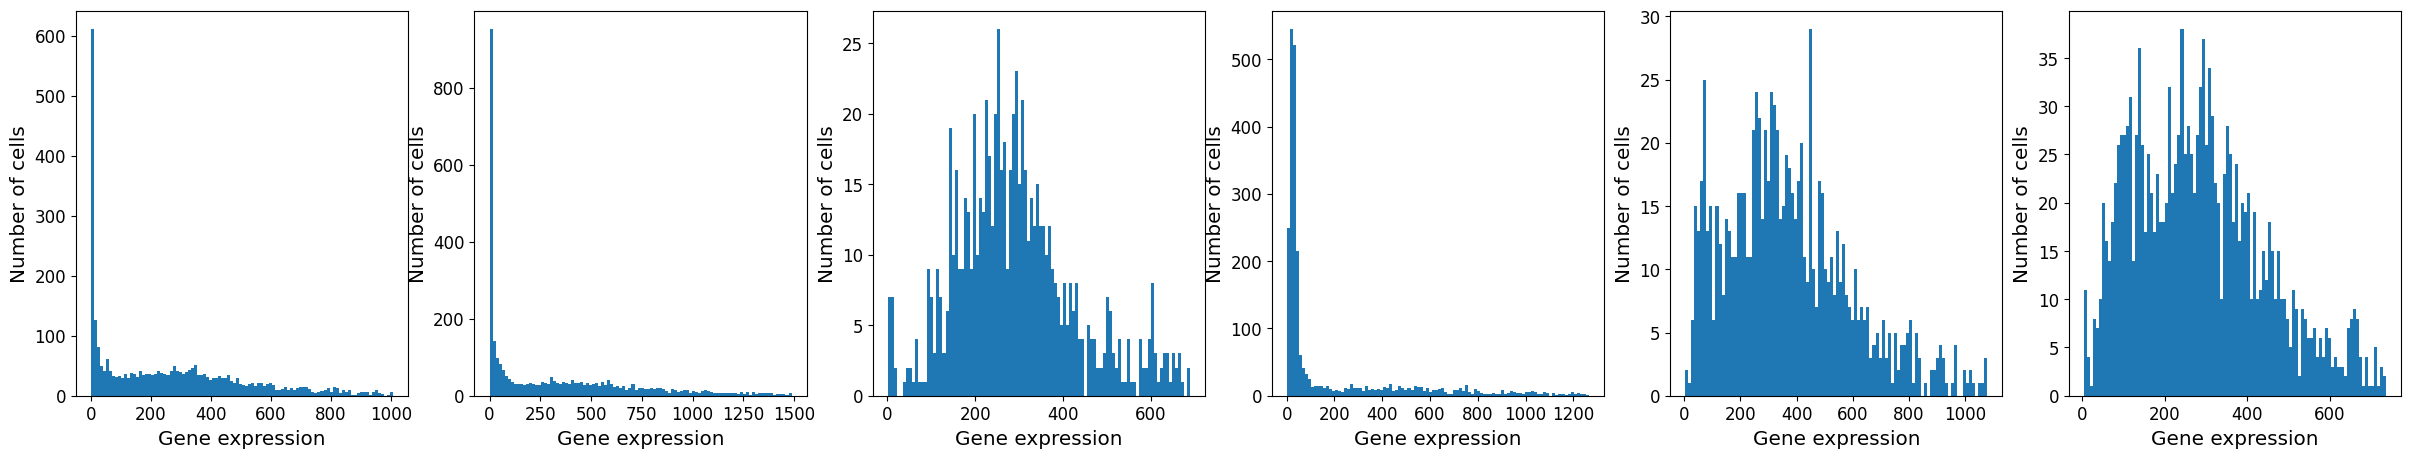

In [8]:
mt_genes = list(
    set.intersection(
        *[
            set(s)
            for s in [
                [g for g in dat.columns if g.startswith("MT-")]
                for dat in data_list_filt.values()
            ]
        ]
    )
)

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, percentile=96, ax=ax)

for s, dat in data_list_filt.items():
    print(f"before mito filt{s}: {dat.shape}")
    dat = scprep.filter.filter_gene_set_expression(
        data=dat, genes=mt_genes, percentile=96, keep_cells="below"
    )
    print(f"after mito filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, ax=ax)

In [9]:
# read paper's meta
import pandas as pd
from anndata import AnnData

adata_list = []
for s, dat in data_list_filt.items():
    adata = AnnData(dat)
    adata.obs["sample_labels"] = s
    adata.obs["barcode"] = adata.obs.index
    adata.obs["Time and replicate"] = (
        s.split("_")[-2] + " Gastruloid Rep " + s.split("_")[-1]
    )
    adata.obs["stage"] = s.split("_")[-2]
    rep_id = [s[-1] for s in adata.obs["sample_labels"].str.split("_")]
    adata.obs.index = pd.Index(
        adata.obs.index.str.cat(adata.obs["sample_labels"], sep="_")
    )
    adata_list.append(adata)
adata = sc.concat(adata_list)
# merge meta
meta = pd.read_csv(data_path / "GSE169074_gastruloid.all.time.metadata.csv.gz")
meta["barcode"] = [s[0] for s in meta["Cell ID"].str.split("_")]
meta = adata.obs.merge(meta, how="left", on=["barcode", "Time and replicate"])
meta.index = adata.obs.index
adata.obs = meta
mic.io.upload_minn_adata(adata, processing_stage="qc")

Saving AnnData to /tmp/tmpl9jn11vh/minn_gastruloid_0-24h_qc_20260211.h5ad
Uploading to s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260211.h5ad


100%|██████████| 1/1 [00:18<00:00, 18.39s/it]

Upload complete: s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260211.h5ad


In [11]:
adata

AnnData object with n_obs × n_vars = 11844 × 13035
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'

# Integration

In [5]:
mic.io.fetch_minn(cwd, type="adata", stage="qc")

100%|██████████| 1/1 [03:25<00:00, 205.66s/it]


In [6]:
mic.io.fetch_heemskerk(cwd)

100%|██████████| 1/1 [15:01<00:00, 901.58s/it]


100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


In [11]:
adata_minn = mic.io.MINN_ADATA_LIST["qc"]
adata_heemskerk = mic.io.HEEMSKERK_ADATA["adata"]
meta_heemskerk = mic.io.HEEMSKERK_ADATA["meta"]
minn_data_path = cwd / "minn_data"
heemskerk_data_path = cwd / "heemskerk_data"
adata_minn = sc.read_h5ad(minn_data_path / adata_minn)
adata_heemskerk = sc.read_h5ad(heemskerk_data_path / adata_heemskerk)
meta_heemskerk = pd.read_csv(heemskerk_data_path / meta_heemskerk, index_col=0)
adata_heemskerk.obs = meta_heemskerk.loc[adata_heemskerk.obs.index]
print(adata_minn)
print(adata_heemskerk)
print(
    f"{len(set.intersection(set(adata_heemskerk.var_names), set(adata_minn.var_names)))} genes in common"
)
adata_heemskerk.obs["source"] = "heemskerk"
adata_minn.obs["source"] = "minn"
adata = sc.concat([adata_heemskerk, adata_minn])
print(adata)
adata.obs = pd.concat([adata_heemskerk.obs, adata_minn.obs])

AnnData object with n_obs × n_vars = 11844 × 13035
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'
AnnData object with n_obs × n_vars = 62402 × 16519
    obs: 'sample_labels', 'leiden_sub', 'leiden_sub_sub2', 'branch_joint', 'dpt_pseudotime', 'leiden_sub_colors', 'leiden_sub_sub2_colors', 'umap_old_48-96h_x', 'umap_old_48-96h_y', 'umap_new_D4-10_x', 'umap_new_D4-10_y'
11434 genes in common
AnnData object with n_obs × n_vars = 74246 × 11434
    obs: 'sample_labels', 'source'


In [12]:
cc_genes = mic.io.read_cc_list(cwd)

100%|██████████| 1/1 [00:00<00:00, 12.19it/s]


In [13]:
mic.utils.normalize_and_select_hvg(adata, n_top_genes=650)

2026-02-13 15:27:17.656 | INFO     | micropattern.utils:normalize_and_select_hvg:57 - Copying X to counts layer before normalization
2026-02-13 15:27:19.066 | INFO     | micropattern.utils:normalize_and_select_hvg:61 - Normalizing to target sum 10000.0 and applying log1p transformation
2026-02-13 15:27:21.907 | INFO     | micropattern.utils:normalize_and_select_hvg:83 - Saving X to raw before computing HVG
2026-02-13 15:27:21.909 | INFO     | micropattern.utils:normalize_and_select_hvg:87 - Computing top 650 highly variable genes (seurat_v3)


In [14]:
cc_genes_all = [g for gl in cc_genes.values() for g in gl]
cc_genes_all = [
    g
    for g in adata.var_names
    if g.split()[0] in cc_genes_all and g not in adata.obs.columns
]
print(f"Insert {len(cc_genes_all)} cc genes into obs")
adata.obs = pd.concat([adata.obs, adata[:, cc_genes_all].to_df()], axis=1)

Insert 39 cc genes into obs


In [19]:
mic.integration.integration(
    adata,
    run_name="minn_heemskerk_micropatern_0-10d_650hvg_70lv",
    categorical_covariates_keys=None,
    continuous_covariates_keys=cc_genes_all,
    n_latent=70,
    lr=1e-5,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: Th

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
Creating tarball 20260213_SCVI_minn_heemskerk_micropatern_0-10d_650hvg_70lv.tar.gz
Uploading to s3://stan-sequencing-data/processed-active/models/20260213_SCVI_minn_heemskerk_micropatern_0-10d_650hvg_70lv.tar.gz


100%|██████████| 1/1 [00:04<00:00,  4.73s/it]

Upload complete: s3://stan-sequencing-data/processed-active/models/20260213_SCVI_minn_heemskerk_micropatern_0-10d_650hvg_70lv.tar.gz


In [ ]:
sc.set_figure_params(figsize=(5, 5))
sc.pp.neighbors(adata, n_neighbors=20, use_rep="X_scvi", random_state=0)

In [ ]:
sc.tl.umap(adata, min_dist=0.01, random_state=0)

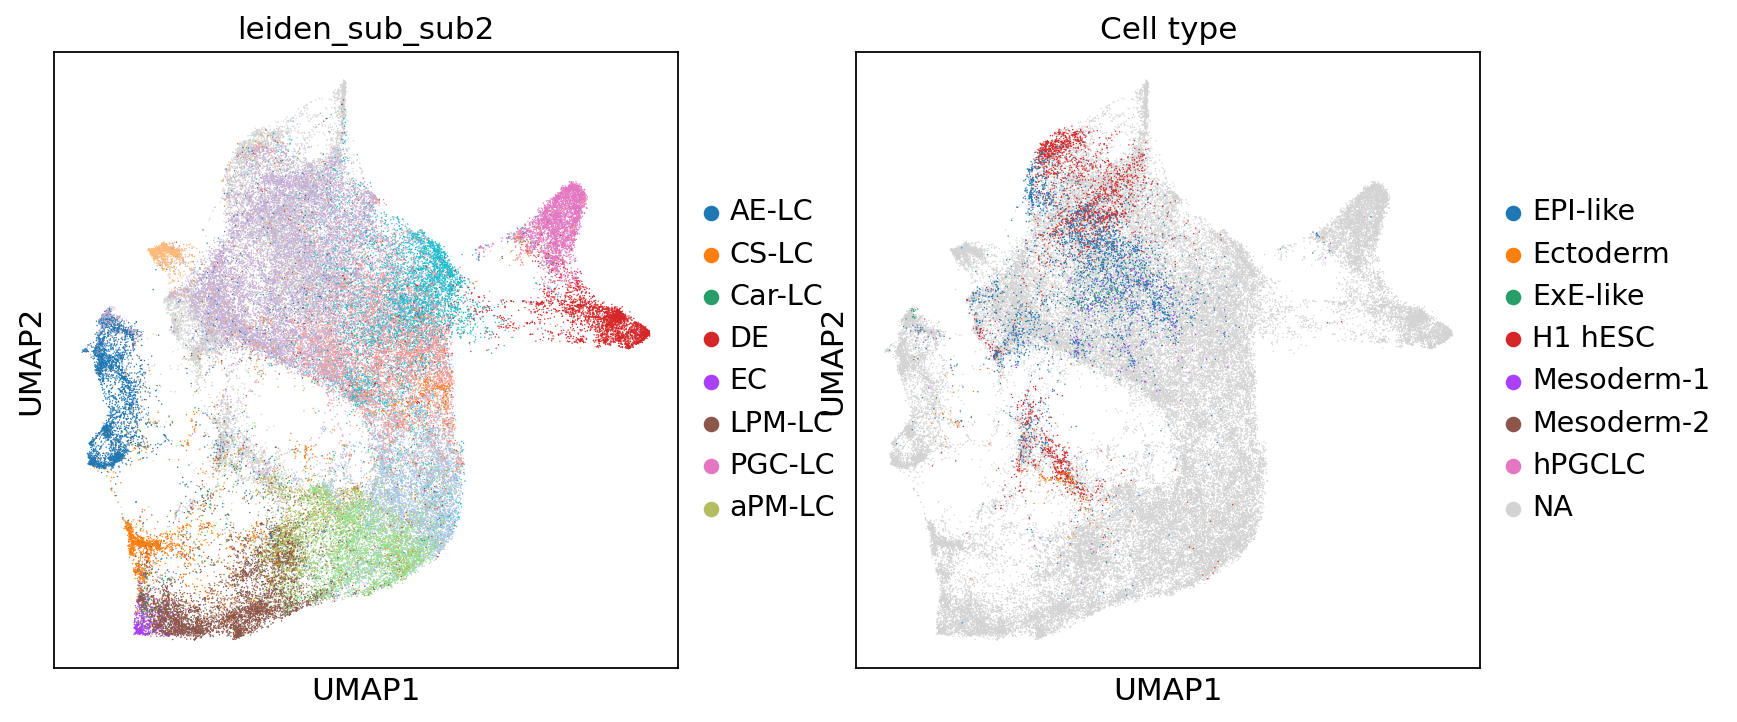

In [ ]:
sc.pl.umap(adata, color=["leiden_sub_sub2", "Cell type"])

In [ ]:
ax = sc.pl.umap(adata, basis="X_all2heemskerk", show=False)
sc.pl.umap(
    adata[adata.obs["sample_labels"].str.contains("GSM")],
    basis="X_all2heemskerk",
    color="Cell type",
    ax=ax,
    size=10,
)

KeyError: "Could not find 'X_all2heemskerk' or 'X_X_all2heemskerk' in .obsm"

In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("./20260213_SCVI_minn_heemskerk_micropatern_0-10d/adata.h5ad")

In [9]:
sc.pp.neighbors(adata, use_rep="X_scvi")
sc.tl.umap(adata, min_dist=0.01)

/home/stanfish/Git/micropattern/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
adata.obs

,sample_labels,leiden_sub,leiden_sub_sub2,branch_joint,dpt_pseudotime,leiden_sub_colors,leiden_sub_sub2_colors,umap_old_48-96h_x,umap_old_48-96h_y,umap_new_D4-10_x,...,TFAP2A (ENSG00000137203),TOP2A (ENSG00000131747),TPX2 (ENSG00000088325),TTLL7 (ENSG00000137941),TUBA1A (ENSG00000167552),UBE2C (ENSG00000175063),USP53 (ENSG00000145390),_scvi_batch,_scvi_labels,observed_lib_size
AAACAAGCAACGACTAATCATGTG-1_48h,48h-2,AE-LC,AE-LC,NaN,0.195301,#1f77b4,#1f77b4,4.550796,3.389241,2.060095,...,1.101465,1.101465,0.849743,0.0,0.512538,1.738124,0.512538,1,0,2046.0
AAACAAGCAGCAATTGATCATGTG-1_48h,48h-2,pluripotent,pluripotent,b100,0.029586,#8c564b,#8c564b,-1.834091,-0.314210,-3.985729,...,0.000000,1.451702,1.626880,0.0,0.597514,1.239181,0.597514,1,0,1292.0
AAACAAGCATCAGGACATCATGTG-1_48h,48h-2,pluripotent,pluripotent,b100,0.052390,#8c564b,#8c564b,-1.592835,0.877822,-2.345336,...,0.000000,0.000000,0.912141,0.0,0.556653,0.000000,0.000000,1,0,1576.0
AAACAAGCATCCCTCTATCATGTG-1_48h,48h-2,aPS-LC,aPS-LC,NaN,0.080348,#aec7e8,#aec7e8,-2.002303,2.401889,-1.292433,...,0.000000,1.811806,0.995902,0.0,0.450473,1.186690,0.759922,1,0,2059.0
AAACAAGCATTCATGCATCATGTG-1_48h,48h-2,pluripotent,pluripotent,b100,0.022161,#8c564b,#8c564b,-0.818049,0.489762,-2.068589,...,0.000000,1.146986,0.000000,0.0,1.351941,0.000000,0.888903,1,0,1439.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGTCCCACG-1_GSM5176723_gastruloid_24h_2,GSM5176723_gastruloid_24h_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.880407,1.466423,0.0,2.172322,2.397996,0.000000,11,0,1553.0
TTTGTCACATCCCACT-1_GSM5176723_gastruloid_24h_2,GSM5176723_gastruloid_24h_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.937472,1.412702,0.0,2.078295,1.585923,0.000000,11,0,2017.0
TTTGTCAGTGCAGGTA-1_GSM5176723_gastruloid_24h_2,GSM5176723_gastruloid_24h_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.720376,0.763912,0.0,1.907064,1.907064,0.000000,11,0,1288.0
TTTGTCAGTGCGATAG-1_GSM5176723_gastruloid_24h_2,GSM5176723_gastruloid_24h_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.060269,1.060269,0.0,2.653949,1.060269,0.664529,11,0,1730.0


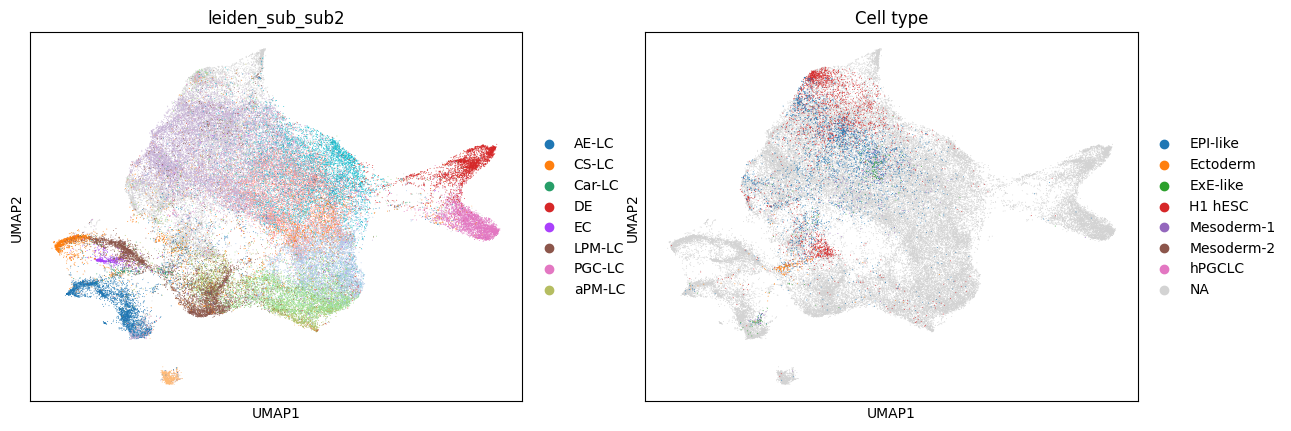

In [12]:
sc.pl.umap(adata, color=["leiden_sub_sub2", "Cell type"])